# Sesion 1 - Introduccion a series temporales no estacionarias (USD/EUR)

Este notebook recorre un flujo completo y realista de trabajo con una serie financiera: limpieza, EDA, modelado base, validacion temporal y lectura de riesgo.

Objetivos didacticos de la sesion:
- Entender como razona un data scientist ante una serie ruidosa y no estacionaria.
- Diferenciar entre objetivo de precision puntual y objetivo de gestion de incertidumbre.
- Aprender a comparar modelos con criterio temporal (no solo por ajuste in-sample).

Enfoque practico de sector financiero:
- **medio plazo**: tendencia + rango de riesgo (horizonte maximo 6 meses)
- **corto plazo**: rolling origin de 1 a 7 dias para seguimiento fino

Mensaje clave:
- En este tipo de serie, el objetivo practico no es acertar exactamente el valor de manana, sino estimar un rango probable y su incertidumbre para apoyar decisiones de riesgo.




## 1) Librerias y configuracion

In [1]:
# Importamos solo las librerias necesarias para limpieza, visualizacion y el primer modelo ARIMA.
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

## 2) Carga, parseo de fecha y construccion de fichero limpio

Pasos:
1. Cargar el CSV original.
2. Filtrar `USD/EUR`.
3. Parsear fecha y renombrar columnas.
4. Reindexar a frecuencia de dias laborables (`B`) para evitar problemas de indice temporal en modelado.
5. Guardar fichero limpio en `data/processed`.

Controles de calidad que se aplican (y que debes reutilizar en futuros proyectos):
- orden temporal correcto
- indice sin huecos no justificados
- tipo numerico consistente
- trazabilidad del dataset procesado



In [2]:
# Leemos el fichero bruto original tal y como llega del proveedor de datos.
raw_path = "../data/raw/tipos_cambio.csv"
df_raw = pd.read_csv(raw_path)

# Filtramos la serie objetivo de esta sesion
# Filtramos la unica divisa que vamos a estudiar en este notebook.
df = df_raw[df_raw["Divisa"] == "USD/EUR"].copy()

# Parseamos fecha y dejamos nombres simples
# Convertimos la fecha a datetime para que pandas pueda operar temporalmente sin ambiguedades.
df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True)
df = df.rename(columns={"Fecha": "date", "Tipo de Cambio": "y"})
df["y"] = pd.to_numeric(df["y"], errors="coerce")
df = df[["date", "y"]].sort_values("date").dropna().reset_index(drop=True)

# Pasamos a indice temporal
# El indice temporal es la estructura base para series temporales en pandas.
df = df.set_index("date")

# Reindexamos a frecuencia laborable para tener un indice regular
# Reindexar a frecuencia laborable regulariza la serie y explicita dias de mercado cerrados.
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="B")
df = df.reindex(full_index)

# Rellenamos huecos de festivos con forward-fill (simple y explicable)
# Forward-fill es una imputacion sencilla y razonable cuando no hay cotizacion por cierre de mercado.
df["y"] = df["y"].ffill()

df.head()

,y
1999-01-04,1.1789
1999-01-05,1.1790
1999-01-06,1.1743
1999-01-07,1.1632
1999-01-08,1.1659


In [3]:
# Comprobamos integridad basica para asegurarnos de que la serie ya es modelable.
print("Filas finales:", len(df))
print("Fecha min:", df.index.min())
print("Fecha max:", df.index.max())
print("Nulos en y:", df["y"].isna().sum())

Filas finales: 6782
Fecha min: 1999-01-04 00:00:00
Fecha max: 2024-12-31 00:00:00
Nulos en y: 0


In [4]:
# Guardamos el dataset limpio para reutilizarlo en otras sesiones o ejercicios.
clean_path = "../data/processed/fx_usd_eur_clean.csv"
df.reset_index().rename(columns={"index": "date"}).to_csv(clean_path, index=False)
print("Fichero limpio guardado en:", clean_path)

Fichero limpio guardado en: ../data/processed/fx_usd_eur_clean.csv


## 3) EDA rapido y visualizacion temporal

Primero vemos la serie completa y despues un zoom de los dos ultimos anos para inspeccionar mejor cambios rapidos y la media movil de 30 dias.

Que buscamos en esta fase:
- cambios de nivel o de volatilidad
- tramos con comportamiento diferente (regimenes)
- magnitud de ruido frente a tendencia local

La EDA no es decorativa: define que modelos tienen sentido y que metricas van a ser mas relevantes.



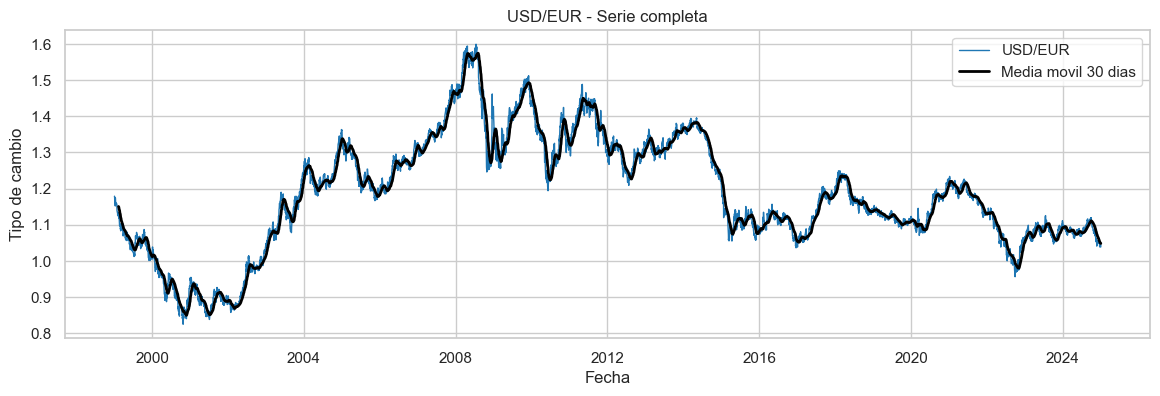

In [5]:
# Media movil para ver tendencia local
# La media movil a 30 dias suaviza ruido y deja ver la tendencia local.
df["ma_30"] = df["y"].rolling(window=30).mean()

# Superponemos serie y suavizado para comparar señal cruda frente a tendencia visual.
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["y"], label="USD/EUR", color="tab:blue", linewidth=1)
plt.plot(df.index, df["ma_30"], label="Media movil 30 dias", color="black", linewidth=2)
plt.title("USD/EUR - Serie completa")
plt.xlabel("Fecha")
plt.ylabel("Tipo de cambio")
plt.legend()
plt.show()

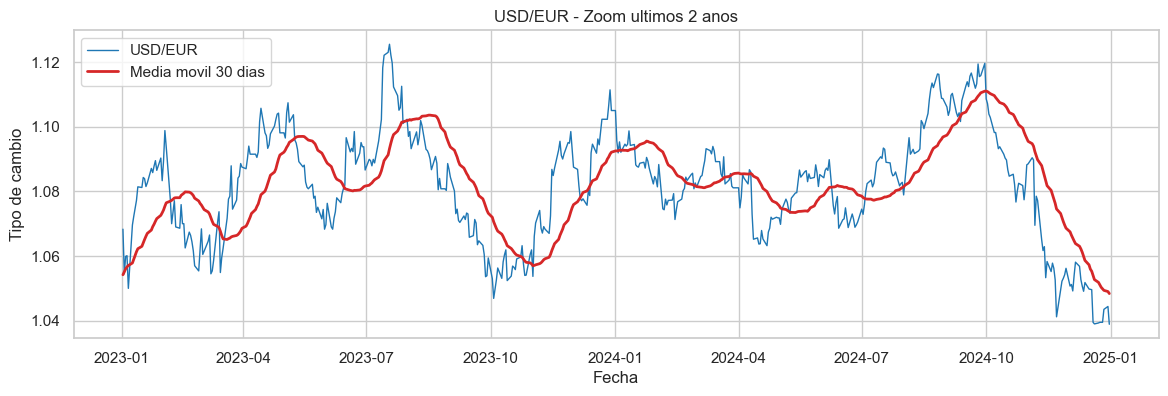

In [6]:
# Zoom adicional: ultimos 2 anos
# Este zoom reciente sirve para detectar cambios de regimen no evidentes en la serie completa.
last_date = df.index.max()
start_zoom = last_date - pd.DateOffset(years=2)
df_zoom = df.loc[start_zoom:last_date].copy()

plt.figure(figsize=(14, 4))
plt.plot(df_zoom.index, df_zoom["y"], label="USD/EUR", color="tab:blue", linewidth=1)
plt.plot(df_zoom.index, df_zoom["ma_30"], label="Media movil 30 dias", color="tab:red", linewidth=2)
plt.title("USD/EUR - Zoom ultimos 2 anos")
plt.xlabel("Fecha")
plt.ylabel("Tipo de cambio")
plt.legend()
plt.show()

## 4) Forecast: baseline vs ARIMA

En esta seccion comparamos dos modelos y su utilidad real en finanzas.

### 4.1 Baseline (naive)
- Idea: predecir el futuro con el ultimo valor observado.
- Uso: referencia minima para saber si un modelo mas complejo realmente mejora.

### 4.2 ARIMA(p,d,q)
ARIMA (AutoRegressive Integrated Moving Average) es un modelo clasico para pronosticar series temporales univariantes cuando el valor actual depende de su propio pasado y del comportamiento reciente del error.

Cuando suele usarse en practica:
- Series sin estacionalidad fuerte o donde la estacionalidad ya se trato aparte.
- Casos donde se necesita un modelo interpretable, rapido y robusto como baseline serio.
- Entornos operativos (riesgo, tesoreria, demanda) donde interesa tanto el punto estimado como su intervalo de confianza.

Intuicion funcional de los parametros `p`, `d`, `q`:
- `d` (Integrated): cuantas diferencias aplicamos para estabilizar la serie.
  - `d=0`: ya estacionaria.
  - `d=1`: modelamos cambios entre periodos consecutivos (muy comun en precios FX).
  - `d=2`: solo si aun hay tendencia fuerte tras una primera diferencia.
- `p` (AutoRegressive): cuantos rezagos de la serie diferenciada usamos para explicar el presente.
  - `p=1`: el ultimo rezago pesa en la prediccion.
  - `p=2`: entran los dos ultimos rezagos, util si hay memoria corta algo mas rica.
- `q` (Moving Average): cuantos rezagos del error reciente corregimos en la prediccion.
  - `q=1`: corrige con el ultimo error, util cuando hay shocks transitorios.
  - `q=2`: corrige con dos errores recientes si hay patron de sobre/sub-correccion.

Ejemplos funcionales rapidos:
- `ARIMA(0,1,0)`: random walk con drift opcional; baseline comun en activos financieros.
- `ARIMA(1,1,0)`: cambio actual influido por el ultimo cambio observado.
- `ARIMA(0,1,1)`: cambio actual corregido por el ultimo error del modelo.
- `ARIMA(1,1,1)`: combina inercia de corto plazo (`p`) y correccion de error (`q`) tras diferenciar (`d=1`).

En este notebook usamos `ARIMA(1,1,1)` como configuracion introductoria porque suele capturar bien dinamica de corto plazo en series no estacionarias sin sobredimensionar el modelo.
Tambien calculamos intervalos de confianza del 95% para cada forecast.

Configuracion temporal de este bloque:
- **Entrenamiento**: ultimos 3 anos
- **Forecast/test**: ultimos 6 meses

Punto clave de interpretacion: en series FX suele ser mas util el intervalo de confianza (entre que y que podria moverse el precio) que el acierto exacto punto a punto.
En banca y tesoreria, este rango ayuda a medir riesgo y a decidir tamano o direccion de posicion.



In [7]:
# Split temporal fijo: 3 anos train + 6 meses test
# Aproximacion en dias laborables: 252 dias ~ 1 ano
# Definimos un split temporal estricto: train en pasado y test en el futuro.
forecast_h = 126        # ~6 meses laborables
train_window = 252 * 3  # ~3 anos laborables

# Verificamos que la muestra tiene tamano suficiente antes de construir el split.
if len(df) < (forecast_h + train_window):
    raise ValueError("No hay suficientes datos para 3 anos train + 6 meses test")

test = df.iloc[-forecast_h:].copy()
train = df.iloc[-(forecast_h + train_window):-forecast_h].copy()

print("Train:", train.index.min(), "->", train.index.max(), "|", len(train), "filas")
print("Test:", test.index.min(), "->", test.index.max(), "|", len(test), "filas")



Train: 2021-08-16 00:00:00 -> 2024-07-08 00:00:00 | 756 filas
Test: 2024-07-09 00:00:00 -> 2024-12-31 00:00:00 | 126 filas


In [8]:
# Modelo 1: baseline naive
# El baseline naive replica el ultimo valor observado; es el minimo a batir.
naive_pred = pd.Series(train["y"].iloc[-1], index=test.index)

# Intervalo simple del baseline
# Usamos la variabilidad de los cambios diarios para construir un intervalo simple alrededor del naive.
sigma_naive = train["y"].diff().dropna().std()
naive_lower = naive_pred - 1.96 * sigma_naive
naive_upper = naive_pred + 1.96 * sigma_naive

In [9]:
# Modelo 2: ARIMA(1,1,1)
# Nota: al tener indice regular (freq='B'), evitamos el ValueWarning tipico de frecuencia.
# ARIMA(1,1,1) combina diferenciacion, memoria autorregresiva y ruido suavizado por media movil.
arima = ARIMA(train["y"], order=(1, 1, 1))
arima_fit = arima.fit()

# El objeto forecast devuelve tanto prediccion puntual como intervalo de confianza.
arima_fc = arima_fit.get_forecast(steps=len(test))
arima_pred = arima_fc.predicted_mean
arima_ci = arima_fc.conf_int(alpha=0.05)
arima_lower = arima_ci.iloc[:, 0]
arima_upper = arima_ci.iloc[:, 1]

In [10]:
# Encapsulamos RMSE en una funcion para reutilizarla de forma clara.
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

mae_naive = mean_absolute_error(test["y"], naive_pred)
rmse_naive = rmse(test["y"], naive_pred)

mae_arima = mean_absolute_error(test["y"], arima_pred)
rmse_arima = rmse(test["y"], arima_pred)

# Reunimos las metricas en una tabla para comparar modelos de un vistazo.
metrics = pd.DataFrame(
    {
        "Modelo": ["Naive", "ARIMA(1,1,1)"],
        "MAE": [mae_naive, mae_arima],
        "RMSE": [rmse_naive, rmse_arima],
    }
)
metrics

,Modelo,MAE,RMSE
0,Naive,0.019885,0.023832
1,"ARIMA(1,1,1)",0.019959,0.023827


### Interpretacion de MAE y RMSE
- **MAE (Mean Absolute Error)**: error medio absoluto. Es facil de interpretar en unidades de la serie.
- **RMSE (Root Mean Squared Error)**: raiz del error cuadratico medio. Penaliza mas los errores grandes.

En general, menor MAE y menor RMSE implican mejor ajuste predictivo en el conjunto de test.

Importante: en FX diario, incluso modelos mas complejos pueden no superar de forma clara a Naive.
Esto es una conclusion valida del ejercicio: el objetivo principal no es "adivinar manana" con precision exacta, sino estimar tendencia probable y rango de variacion con una confianza explicita.

Regla metodologica para decision:
- usa MAE/RMSE para precision puntual
- usa cobertura IC95 y % fuera de IC para calibracion de riesgo
- si un modelo mejora muy poco MAE pero empeora calibracion, no siempre es mejor para negocio



In [11]:
# No solo imprimimos metricas: tambien interpretamos si la mejora del modelo es real o marginal.
print("Resultados en test:")
print(f"Naive  -> MAE: {mae_naive:.6f} | RMSE: {rmse_naive:.6f}")
print(f"ARIMA  -> MAE: {mae_arima:.6f} | RMSE: {rmse_arima:.6f}")

if mae_arima < mae_naive and rmse_arima < rmse_naive:
    print("Interpretacion: ARIMA mejora al baseline en ambas metricas.")
elif mae_arima < mae_naive or rmse_arima < rmse_naive:
    print("Interpretacion: ARIMA mejora parcialmente al baseline.")
else:
    print("Interpretacion: el baseline rinde igual o mejor que ARIMA en este split.")

Resultados en test:
Naive  -> MAE: 0.019885 | RMSE: 0.023832
ARIMA  -> MAE: 0.019959 | RMSE: 0.023827
Interpretacion: ARIMA mejora parcialmente al baseline.


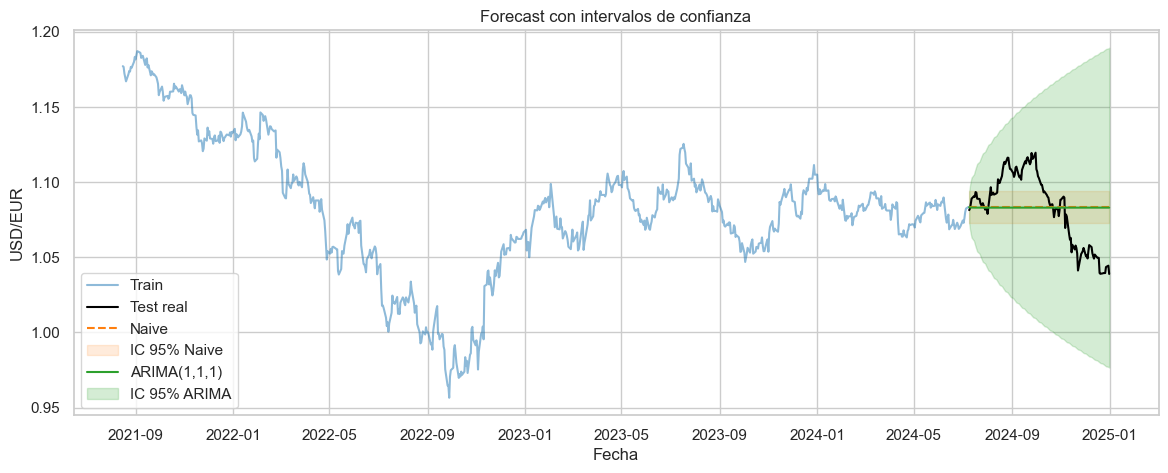

In [12]:
# Esta figura junta train, test y los dos modelos para analizar sesgo y dispersion.
plt.figure(figsize=(14, 5))
plt.plot(train.index, train["y"], label="Train", color="tab:blue", alpha=0.5)
plt.plot(test.index, test["y"], label="Test real", color="black")

plt.plot(test.index, naive_pred, label="Naive", color="tab:orange", linestyle="--")
plt.fill_between(test.index, naive_lower, naive_upper, color="tab:orange", alpha=0.15, label="IC 95% Naive")

plt.plot(test.index, arima_pred, label="ARIMA(1,1,1)", color="tab:green")
plt.fill_between(test.index, arima_lower, arima_upper, color="tab:green", alpha=0.2, label="IC 95% ARIMA")

plt.title("Forecast con intervalos de confianza")
plt.xlabel("Fecha")
plt.ylabel("USD/EUR")
plt.legend(loc="best")
plt.show()

## 5) Backtesting rolling origin

### Concepto
El **rolling origin** simula el uso real del modelo en el tiempo:
1. Entrenar con datos hasta una fecha.
2. Predecir el siguiente punto.
3. Avanzar una fecha y repetir.

Ventaja: mide rendimiento en un flujo temporal real, sin mezclar pasado y futuro.

### Enfoque practico
- En este bloque mantenemos rolling a 1 dia para construir la base.
- En el cierre comparativo (ARIMA vs NHITS) extendemos la vision a **1 y 7 dias**.

### Evaluacion de intervalos
No basta con MAE/RMSE. Tambien se evalua la calidad del intervalo de confianza.
- Para un IC del 95%, esperamos que la serie quede fuera del intervalo alrededor del 5% de las veces.
- Si se sale mucho mas, el modelo infravalora el riesgo (intervalo demasiado estrecho).
- Si se sale mucho menos, el intervalo puede ser demasiado conservador (demasiado ancho).

### Nota sobre `ValueWarning`
Si Statsmodels muestra `ValueWarning` por frecuencia de fechas, suele deberse a un indice sin `freq` definida.
Aqui lo prevenimos reindexando a `freq='B'` en la seccion de limpieza.

### Limitaciones del bloque
- El backtesting es de una sola serie y una configuracion base de modelos.
- No incluye variables exogenas (tipos, spreads, eventos macro).
- La lectura final debe ser prudente: resultados historicos no garantizan rendimiento futuro.



In [13]:
# Backtesting rapido sobre los ultimos 250 puntos
# El rolling-origin simula predicciones repetidas en tiempo real sobre el tramo mas reciente.
bt_series = df["y"].iloc[-250:].copy()

real_bt = []
naive_bt = []
arima_bt = []
arima_bt_lower = []
arima_bt_upper = []
dates_bt = []

# Arranque en 70% para tener historia minima
# Empezamos tras acumular suficiente historia para que ARIMA pueda estimarse con estabilidad.
start = int(len(bt_series) * 0.7)

# En cada iteracion usamos solo el pasado disponible hasta ese instante: no hay leakage.
for i in range(start, len(bt_series)):
    history = bt_series.iloc[:i]
    y_real = bt_series.iloc[i]

    # Naive 1-step
    y_naive = history.iloc[-1]

    # ARIMA 1-step con intervalo de confianza al 95%
    model_bt = ARIMA(history, order=(1, 1, 1)).fit()
    fc_bt = model_bt.get_forecast(steps=1)
    y_arima = fc_bt.predicted_mean.iloc[0]
    ci_bt = fc_bt.conf_int(alpha=0.05)
    y_arima_lower = ci_bt.iloc[0, 0]
    y_arima_upper = ci_bt.iloc[0, 1]

    real_bt.append(y_real)
    naive_bt.append(y_naive)
    arima_bt.append(y_arima)
    arima_bt_lower.append(y_arima_lower)
    arima_bt_upper.append(y_arima_upper)
    dates_bt.append(bt_series.index[i])

# Convertimos la salida acumulada a DataFrame para medir error y cobertura.
bt = pd.DataFrame(
    {
        "date": dates_bt,
        "y_real": real_bt,
        "y_naive": naive_bt,
        "y_arima": arima_bt,
        "y_arima_lower": arima_bt_lower,
        "y_arima_upper": arima_bt_upper,
    }
).set_index("date")

bt_mae_naive = mean_absolute_error(bt["y_real"], bt["y_naive"])
bt_rmse_naive = rmse(bt["y_real"], bt["y_naive"])

bt_mae_arima = mean_absolute_error(bt["y_real"], bt["y_arima"])
bt_rmse_arima = rmse(bt["y_real"], bt["y_arima"])

print("Backtesting rolling origin (1-step):")
print(f"Naive  -> MAE: {bt_mae_naive:.6f} | RMSE: {bt_rmse_naive:.6f}")
print(f"ARIMA  -> MAE: {bt_mae_arima:.6f} | RMSE: {bt_rmse_arima:.6f}")

# Cobertura del intervalo ARIMA en backtesting
# La cobertura mide que proporcion de reales cae dentro del intervalo al 95%.
inside_ic_arima = ((bt["y_real"] >= bt["y_arima_lower"]) & (bt["y_real"] <= bt["y_arima_upper"]))
coverage_arima = inside_ic_arima.mean()
outside_arima = 1 - coverage_arima

print(f"Cobertura IC 95% ARIMA: {coverage_arima*100:.2f}%")
print(f"Fuera del IC 95% ARIMA: {outside_arima*100:.2f}%")
print("Referencia teorica para IC 95%: ~5% fuera del intervalo")


c:\Users\julio\Documents\DemoCode\TimeSeries\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\julio\Documents\DemoCode\TimeSeries\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\julio\Documents\DemoCode\TimeSeries\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\julio\Documents\DemoCode\TimeSeries\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed t

Backtesting rolling origin (1-step):
Naive  -> MAE: 0.003296 | RMSE: 0.004773
ARIMA  -> MAE: 0.003343 | RMSE: 0.004841
Cobertura IC 95% ARIMA: 90.67%
Fuera del IC 95% ARIMA: 9.33%
Referencia teorica para IC 95%: ~5% fuera del intervalo


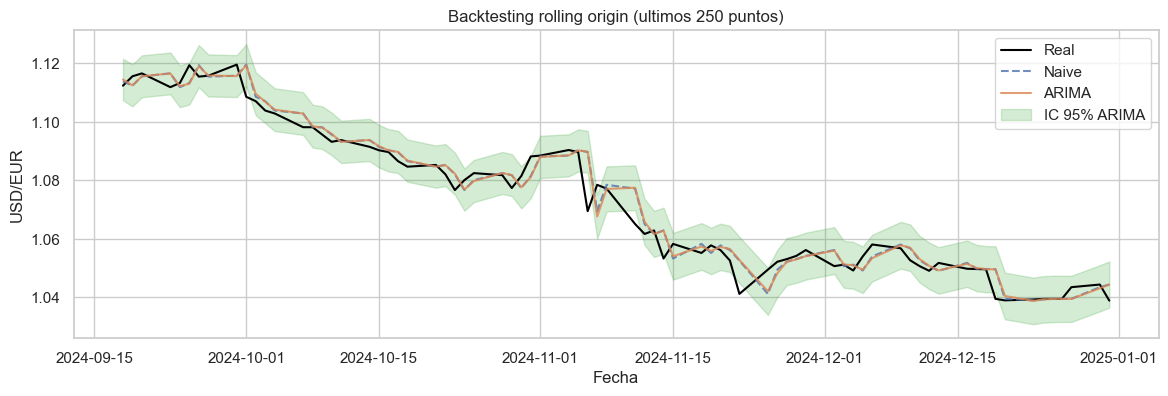

In [14]:
# Esta figura resume visualmente el backtesting rolling y la cobertura del intervalo ARIMA.
plt.figure(figsize=(14, 4))
plt.plot(bt.index, bt["y_real"], label="Real", color="black")
plt.plot(bt.index, bt["y_naive"], label="Naive", linestyle="--", alpha=0.8)
plt.plot(bt.index, bt["y_arima"], label="ARIMA", alpha=0.8)
plt.fill_between(bt.index, bt["y_arima_lower"], bt["y_arima_upper"], color="tab:green", alpha=0.2, label="IC 95% ARIMA")
plt.title("Backtesting rolling origin (ultimos 250 puntos)")
plt.xlabel("Fecha")
plt.ylabel("USD/EUR")
plt.legend()
plt.show()

## 6) Cierre demo financiero: NHITS vs ARIMA

En este cierre hacemos una comparacion orientada a uso real en finanzas:

1. **Forecast medio plazo comparable**
- misma ventana que el bloque principal: 3 anos de train y 6 meses de forecast/test.

2. **Rolling corto plazo 1 dia (opcional)**
- lo dejamos en una celda separada para poder ejecutarlo aparte sin bloquear la clase.

Lectura metodologica esperada:
- un modelo mas sofisticado no siempre domina en todas las metricas
- la eleccion final depende de horizonte, estabilidad, coste operativo y calidad de intervalos



Seed set to 7
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MQLoss        | 3      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.7 M  | train | 0    
---------------------------------------------------------------
3.7 M     Trainable params
3         Non-trainable params
3.7 M     Total params
14.917    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting: |          | 0/? [00:00<?, ?it/s]


Resumen MEDIO PLAZO (3 anos train + 6 meses test):


,Modelo,MAE,RMSE,Cobertura_IC95,%Fuera_IC95
0,"ARIMA(1,1,1)",0.019959,0.023827,1.00000,0.00000
1,NHITS,0.020236,0.024076,0.84127,0.15873


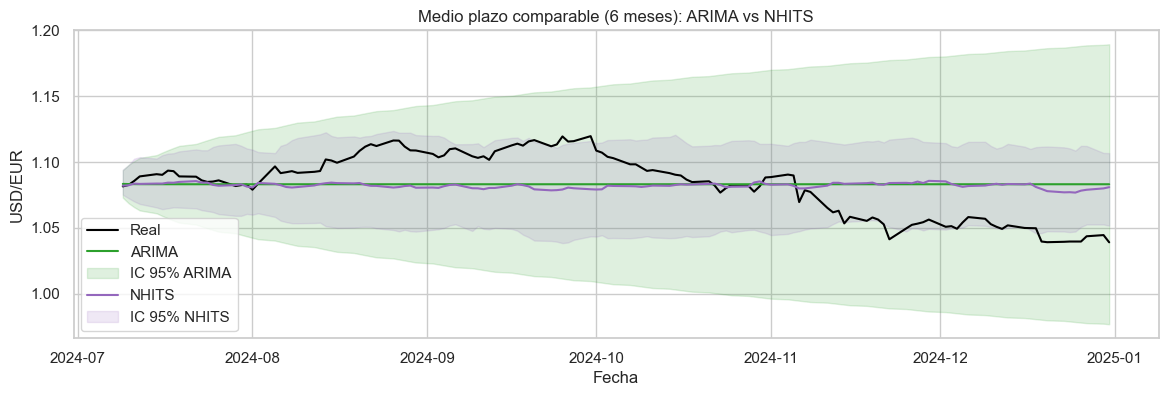

In [15]:
# NHITS vs ARIMA - BLOQUE A: medio plazo (3 anos train + 6 meses test)

# Este bloque opcional compara ARIMA con NHITS en una ventana de medio plazo.
try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import NHITS
    from neuralforecast.losses.pytorch import MQLoss

    forecast_h_demo = 126
    train_window_demo = 252 * 3

    if len(df) < (forecast_h_demo + train_window_demo):
        raise ValueError("No hay suficientes datos para demo NHITS con 3 anos + 6 meses")

    test_cmp = df.iloc[-forecast_h_demo:].copy()
    train_cmp = df.iloc[-(forecast_h_demo + train_window_demo):-forecast_h_demo].copy()

    # Primero entrenamos ARIMA sobre exactamente la misma ventana para que la comparacion sea justa.
    arima_cmp_fit = ARIMA(train_cmp["y"], order=(1, 1, 1)).fit()
    arima_cmp_fc = arima_cmp_fit.get_forecast(steps=len(test_cmp))
    arima_cmp_pred = arima_cmp_fc.predicted_mean
    arima_cmp_ci = arima_cmp_fc.conf_int(alpha=0.05)
    arima_cmp_lo = arima_cmp_ci.iloc[:, 0]
    arima_cmp_hi = arima_cmp_ci.iloc[:, 1]

    # Despues adaptamos los datos al formato requerido por NeuralForecast.
    train_nf = train_cmp.reset_index().rename(columns={"index": "ds"})[["ds", "y"]].copy()
    train_nf["unique_id"] = "USD_EUR"
    train_nf = train_nf[["unique_id", "ds", "y"]]

    nhits_holdout = NHITS(
        h=len(test_cmp),
        input_size=min(400, len(train_nf) - 1),
        max_steps=300,
        loss=MQLoss(level=[95]),
        random_seed=7,
    )

    nf_holdout = NeuralForecast(models=[nhits_holdout], freq="B")
    nf_holdout.fit(df=train_nf)
    fcst_holdout = nf_holdout.predict().reset_index()

    point_col = "NHITS-median" if "NHITS-median" in fcst_holdout.columns else ("NHITS" if "NHITS" in fcst_holdout.columns else None)
    lo_col = "NHITS-lo-95" if "NHITS-lo-95" in fcst_holdout.columns else None
    hi_col = "NHITS-hi-95" if "NHITS-hi-95" in fcst_holdout.columns else None

    if point_col is None:
        cand = [c for c in fcst_holdout.columns if "nhits" in c.lower() and "lo" not in c.lower() and "hi" not in c.lower()]
        if cand:
            point_col = cand[0]
    if lo_col is None:
        cand = [c for c in fcst_holdout.columns if "nhits" in c.lower() and "lo" in c.lower() and "95" in c]
        if cand:
            lo_col = cand[0]
    if hi_col is None:
        cand = [c for c in fcst_holdout.columns if "nhits" in c.lower() and "hi" in c.lower() and "95" in c]
        if cand:
            hi_col = cand[0]

    if point_col is None or lo_col is None or hi_col is None:
        raise ValueError(f"Columnas NHITS no detectadas en holdout. Disponibles: {list(fcst_holdout.columns)}")

    cmp = test_cmp.reset_index().rename(columns={"index": "ds"})[["ds", "y"]].copy()
    cmp["y_arima"] = arima_cmp_pred.values
    cmp["y_arima_lower"] = arima_cmp_lo.values
    cmp["y_arima_upper"] = arima_cmp_hi.values

    tmp = fcst_holdout[["ds", point_col, lo_col, hi_col]].rename(
        columns={point_col: "y_nhits", lo_col: "y_nhits_lower", hi_col: "y_nhits_upper"}
    )
    cmp = cmp.merge(tmp, on="ds", how="left")

    summary_holdout = pd.DataFrame(
        {
            "Modelo": ["ARIMA(1,1,1)", "NHITS"],
            "MAE": [mean_absolute_error(cmp["y"], cmp["y_arima"]), mean_absolute_error(cmp["y"], cmp["y_nhits"])],
            "RMSE": [rmse(cmp["y"], cmp["y_arima"]), rmse(cmp["y"], cmp["y_nhits"])],
            "Cobertura_IC95": [
                ((cmp["y"] >= cmp["y_arima_lower"]) & (cmp["y"] <= cmp["y_arima_upper"])).mean(),
                ((cmp["y"] >= cmp["y_nhits_lower"]) & (cmp["y"] <= cmp["y_nhits_upper"])).mean(),
            ],
        }
    )
    summary_holdout["%Fuera_IC95"] = 1 - summary_holdout["Cobertura_IC95"]

    print("\nResumen MEDIO PLAZO (3 anos train + 6 meses test):")
    display(summary_holdout)

    plt.figure(figsize=(14, 4))
    plt.plot(cmp["ds"], cmp["y"], label="Real", color="black")
    plt.plot(cmp["ds"], cmp["y_arima"], label="ARIMA", color="tab:green")
    plt.fill_between(cmp["ds"], cmp["y_arima_lower"], cmp["y_arima_upper"], color="tab:green", alpha=0.15, label="IC 95% ARIMA")
    plt.plot(cmp["ds"], cmp["y_nhits"], label="NHITS", color="tab:purple")
    plt.fill_between(cmp["ds"], cmp["y_nhits_lower"], cmp["y_nhits_upper"], color="tab:purple", alpha=0.15, label="IC 95% NHITS")
    plt.title("Medio plazo comparable (6 meses): ARIMA vs NHITS")
    plt.xlabel("Fecha")
    plt.ylabel("USD/EUR")
    plt.legend(loc="best")
    plt.show()

except Exception as e:
    print("Bloque NHITS (medio plazo) no ejecutado.")
    print("Si falta dependencia, instala: pip install neuralforecast torch")
    print("Detalle:", e)



### 6.1) Rolling corto plazo (1 dia) - celda separada

Esta celda es opcional y esta separada para controlar tiempos de ejecucion.
Compara **rolling 1 dia** entre ARIMA y NHITS en la misma ventana temporal reducida.



c:\Users\julio\Documents\DemoCode\TimeSeries\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Seed set to 7
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MQLoss        | 3      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 2.5 M  | train | 0    
---------------------------------------------------------------
2.5 M     T

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=80` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=80` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting: |          | 0/? [00:00<?, ?it/s]


Resumen ROLLING corto plazo comparable (1 dia):


,Modelo,MAE,RMSE,Cobertura_IC95,%Fuera_IC95
0,"ARIMA(1,1,1)",0.002135,0.003447,0.928571,0.071429
1,NHITS,0.002225,0.003442,0.928571,0.071429


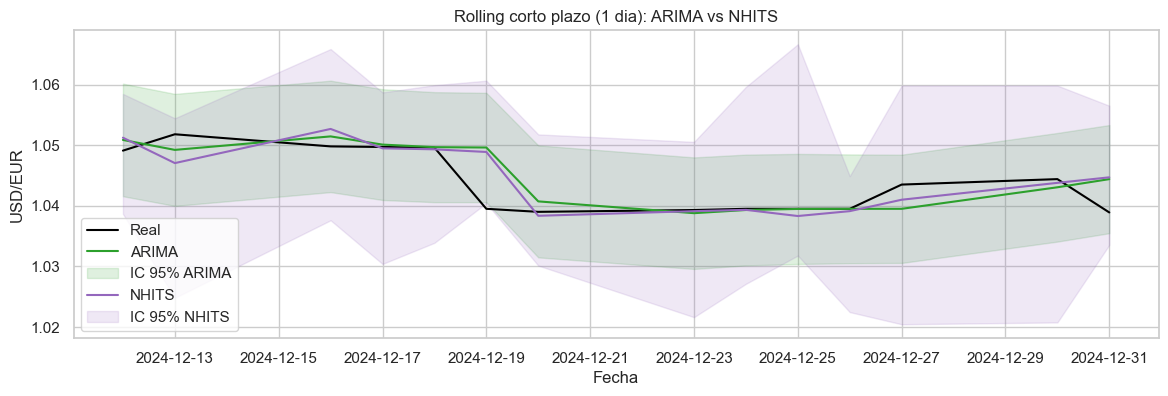

In [16]:
# NHITS vs ARIMA - BLOQUE B: rolling corto plazo 1 dia (opcional)

# Repetimos la comparacion ARIMA vs NHITS, ahora en rolling de 1 dia, que es mas exigente.
try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import NHITS
    from neuralforecast.losses.pytorch import MQLoss

    # Limitamos la ventana para que el ejemplo siga siendo ejecutable en CPU.
    bt_series = df["y"].iloc[-90:].copy()   # ventana reducida para CPU
    start_bt = int(len(bt_series) * 0.85)
    h_roll = 1

    rows = []

    # En cada origen se reentrenan ambos modelos solo con la historia disponible hasta ese punto.
    for i in range(start_bt, len(bt_series) - h_roll + 1):
        history = bt_series.iloc[:i]
        y_real = float(bt_series.iloc[i + h_roll - 1])
        y_date = bt_series.index[i + h_roll - 1]

        # ARIMA 1-step
        ar_fit = ARIMA(history, order=(1, 1, 1)).fit()
        ar_fc = ar_fit.get_forecast(steps=h_roll)
        y_ar = float(ar_fc.predicted_mean.iloc[h_roll - 1])
        ar_ci = ar_fc.conf_int(alpha=0.05)
        y_ar_lo = float(ar_ci.iloc[h_roll - 1, 0])
        y_ar_hi = float(ar_ci.iloc[h_roll - 1, 1])

        # NHITS 1-step
        hist_nf = history.to_frame("y").reset_index().rename(columns={"index": "ds"})[["ds", "y"]].copy()
        hist_nf["unique_id"] = "USD_EUR"
        hist_nf = hist_nf[["unique_id", "ds", "y"]]

        nhits_roll = NHITS(
            h=h_roll,
            input_size=min(60, max(20, len(hist_nf) - 1)),
            max_steps=80,
            loss=MQLoss(level=[95]),
            random_seed=7,
        )

        nf_roll = NeuralForecast(models=[nhits_roll], freq="B")
        nf_roll.fit(df=hist_nf)
        fc_roll = nf_roll.predict().reset_index().sort_values("ds").reset_index(drop=True)

        p_col = "NHITS-median" if "NHITS-median" in fc_roll.columns else ("NHITS" if "NHITS" in fc_roll.columns else None)
        lo_c = "NHITS-lo-95" if "NHITS-lo-95" in fc_roll.columns else None
        hi_c = "NHITS-hi-95" if "NHITS-hi-95" in fc_roll.columns else None

        if p_col is None:
            cand = [c for c in fc_roll.columns if "nhits" in c.lower() and "lo" not in c.lower() and "hi" not in c.lower()]
            if cand:
                p_col = cand[0]
        if lo_c is None:
            cand = [c for c in fc_roll.columns if "nhits" in c.lower() and "lo" in c.lower() and "95" in c]
            if cand:
                lo_c = cand[0]
        if hi_c is None:
            cand = [c for c in fc_roll.columns if "nhits" in c.lower() and "hi" in c.lower() and "95" in c]
            if cand:
                hi_c = cand[0]

        if p_col is None or lo_c is None or hi_c is None:
            raise ValueError(f"Columnas NHITS no detectadas en rolling. Disponibles: {list(fc_roll.columns)}")

        y_nh = float(fc_roll[p_col].iloc[h_roll - 1])
        y_nh_lo = float(fc_roll[lo_c].iloc[h_roll - 1])
        y_nh_hi = float(fc_roll[hi_c].iloc[h_roll - 1])

        rows.append(
            {
                "date": y_date,
                "y_real": y_real,
                "y_arima": y_ar,
                "y_arima_lower": y_ar_lo,
                "y_arima_upper": y_ar_hi,
                "y_nhits": y_nh,
                "y_nhits_lower": y_nh_lo,
                "y_nhits_upper": y_nh_hi,
            }
        )

    bt_cmp = pd.DataFrame(rows).set_index("date")

    summary_roll_1d = pd.DataFrame(
        {
            "Modelo": ["ARIMA(1,1,1)", "NHITS"],
            "MAE": [mean_absolute_error(bt_cmp["y_real"], bt_cmp["y_arima"]), mean_absolute_error(bt_cmp["y_real"], bt_cmp["y_nhits"])],
            "RMSE": [rmse(bt_cmp["y_real"], bt_cmp["y_arima"]), rmse(bt_cmp["y_real"], bt_cmp["y_nhits"])],
            "Cobertura_IC95": [
                ((bt_cmp["y_real"] >= bt_cmp["y_arima_lower"]) & (bt_cmp["y_real"] <= bt_cmp["y_arima_upper"])).mean(),
                ((bt_cmp["y_real"] >= bt_cmp["y_nhits_lower"]) & (bt_cmp["y_real"] <= bt_cmp["y_nhits_upper"])).mean(),
            ],
        }
    )
    summary_roll_1d["%Fuera_IC95"] = 1 - summary_roll_1d["Cobertura_IC95"]

    print("\nResumen ROLLING corto plazo comparable (1 dia):")
    display(summary_roll_1d)

    plt.figure(figsize=(14, 4))
    plt.plot(bt_cmp.index, bt_cmp["y_real"], label="Real", color="black")
    plt.plot(bt_cmp.index, bt_cmp["y_arima"], label="ARIMA", color="tab:green")
    plt.fill_between(bt_cmp.index, bt_cmp["y_arima_lower"], bt_cmp["y_arima_upper"], color="tab:green", alpha=0.15, label="IC 95% ARIMA")
    plt.plot(bt_cmp.index, bt_cmp["y_nhits"], label="NHITS", color="tab:purple")
    plt.fill_between(bt_cmp.index, bt_cmp["y_nhits_lower"], bt_cmp["y_nhits_upper"], color="tab:purple", alpha=0.15, label="IC 95% NHITS")
    plt.title("Rolling corto plazo (1 dia): ARIMA vs NHITS")
    plt.xlabel("Fecha")
    plt.ylabel("USD/EUR")
    plt.legend(loc="best")
    plt.show()

except Exception as e:
    print("Bloque NHITS (rolling 1 dia) no ejecutado.")
    print("Si falta dependencia, instala: pip install neuralforecast torch")
    print("Detalle:", e)



## 7) Enlace con la sesion 2

En FX (serie no estacionaria y muy ruidosa), el foco practico esta en intervalos y riesgo: rango esperado y confianza.

En la siguiente sesion (demanda del metro), la serie tiene estacionalidad mas marcada. Ahi, ademas de medir incertidumbre, el foco pasa a modelar componentes estacionales de forma mas directa y separarlas de la parte aleatoria.

Plantilla reusable para alumnos (base de futuros proyectos):
1. Definir objetivo de negocio y horizonte.
2. Asegurar calidad temporal del dato.
3. Hacer EDA para formular hipotesis.
4. Empezar por baseline interpretable.
5. Comparar con modelos mas complejos en backtesting temporal.
6. Evaluar precision + calibracion de incertidumbre.
7. Documentar limitaciones y supuestos antes de decidir.

